## Come ho scoperto di non essere brava a scacchi

Da quando sono piccola ho sempre pensato che chi giocasse a scacchi avesse un IQ elevatissimo, guardavo le persone giocarci e le associavo ad essere geni. Ogni volta che in un programma tv due persone sono rivali, c'è sempre una scena con una scacchiera in mezzo, per dare il senso di strategia.

Ecco, ora, dopo anni, più cresco e più mi rendo conto di come il tempo passi velocemente, dunque ho deciso di avvicinarmi di più alla me bambina iniziando a fare tutte quellle cose che mi sembravano impossibili, un po' per renderla fiera e sentimi vicina a me stessa in questo turbine di responsabilità da adulta e studente in procinto di finire la sua carriera accademica e affacciarsi sul mondo del lavoro per poter sopravvivere. 

Insomma, ho iniziato a studiare manuali, guardare video su Youtube, comprare libri, (talvolta ignorando lo studio vero e proprio...) e pian piano ho iniziato a migliorare in maniera esponenziale, vincendo molte partite, salendo di punteggio, per poi...per poi rendermi conto di essere tremendamente average, se non sotto la media, e iniziare a perdere molte partite man mano che l'ELO avversario cresceva. E' proprio vero che la curva dell'apprendimento è così. La scalata inizia proprio da qui, però. Così mi son chiesta: a cosa serve guardare tutte queste informazioni esterne, cercare insegnamenti altrove, se magari il migliore insegnante di me stessa posso essere io proprio perchè sono io che mi conosco così bene? Come è che IO, Ilaria, proprio io, reagisco alle vittorie, alle sconfitte, qual è l'approccio migliore che mi aiuta a migliorare e a tirare il meglio da me stessa in base al mio carattere e al mio stile di gioco?

Le domande principali che mi sono posta sono due:
1. Cosa dicono i miei dati sul mio stile di gioco?
2. Cosa dovrei dunque fare per massimizzare le mie chances di vittoria in base alle osservazioni che ne derivano?

Ed è per questo che questo progetto prende vita. Ho deciso di giudicare me stessa e capire il mio stile di gioco nel modo più semplice eppure scontato che esista: guardare ai miei dati. Ed è qui che inizia davvero la scalata verso il miglioramento.



## EN: How I Discovered I'm Not Good at Chess
Growing up, I always believed [chess](https://en.wikipedia.org/wiki/Chess) players were geniuses. The kind of people who think three moves ahead in life, not just on the board. Every time two rivals faced off on TV, there was a chessboard between them — the universal symbol of strategic minds at war. I watched in quiet awe.

Years passed. And as adulthood started closing in — final exams, career choices, the unsettling feeling that time is moving faster than I can keep up — I found myself wanting to close the gap between who I am now and the wide-eyed kid I used to be. So I did what she always wanted to do: I learned to play chess.
I studied openings, watched hours of YouTube, bought books I probably should have read less than I studied for my actual degree. And for a while, it worked. My rating climbed. I was winning. I felt sharp.

Then the losses came. Quietly at first, then relentlessly. Turns out, I'm average — maybe even below it. The learning curve is real, and I had just hit the hard part.
But instead of looking outward — more tutorials, more theory — I asked a different question: what if the best coach for me is me? I know my patterns, my instincts, my weaknesses better than any YouTube channel or theory book ever could. So I decided to do the most honest thing I could think of: look at my own data.
Two questions drove me here:

1. What does my data say about how I actually play?
2. What should I do differently based on what the data show about me to get better at chess?

This project is my attempt at an answer. The climb starts here.

## Retrieving and cleaning my chess.com data

I took my data from the [chess.com](https://www.chess.com), one of the most well-known platform for online chess. They have an [API](https://www.chess.com/news/view/published-data-api) that permits you to gather you own data and take information in JSON-LD format about your games within one month with this structure:
. I decided to gather data from January 2026 to May 2026, that is when I played the most with the request method. The structure of the data retrieved is like that:
bla bla 

I dati che mi interessano li ho messi in un csv così formato:

bla bla bla.


In [1]:
import requests
import pandas as pd
from datetime import datetime
import re
import time
import calendar

username = "amypondz"
year = 2026
months = [1, 2, 3, 4, 5]
headers = {"User-Agent": "0009-0008-2026-5889"}

def get_result(my_result):
    if my_result == "win":
        return "win"
    draw_codes = ["agreed", "repetition", "stalemate", "timevsinsufficient", "insufficient", "50move"]
    return "draw" if my_result in draw_codes else "loss"

def extract_moves(pgn):
    if not pgn:
        return None
    lines = [l for l in pgn.strip().split("\n") if not l.startswith("[")]
    moves_text = " ".join(lines).strip()
    moves_text = re.sub(r"\s*(1-0|0-1|1/2-1/2|\*)\s*$", "", moves_text)
    moves_text = re.sub(r"\{[^}]*\}", "", moves_text)
    moves_text = re.sub(r"\$\d+", "", moves_text)
    return re.sub(r"\s+", " ", moves_text).strip()

all_games = []
game_id = 0

for month in months:
    url = f"https://api.chess.com/pub/player/{username}/games/{year}/{str(month).zfill(2)}"
    print(f"Downloading {url}")
    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        print(f"Errore {response.status_code}")
        continue

    for game in response.json().get("games", []):
        white = game.get("white", {})
        black = game.get("black", {})
        accuracies = game.get("accuracies", {})

        if white.get("username", "").lower() == username.lower():
            my_color, my_data, opp_data = "white", white, black
            my_accuracy, opp_accuracy = accuracies.get("white"), accuracies.get("black")
        else:
            my_color, my_data, opp_data = "black", black, white
            my_accuracy, opp_accuracy = accuracies.get("black"), accuracies.get("white")

        end_dt = datetime.fromtimestamp(game["end_time"])
        start_raw = game.get("start_time")
        start_dt = datetime.fromtimestamp(start_raw) if start_raw else None

        eco_url = game.get("eco", "")
        opening = None
        eco = None
        if eco_url:
            opening = eco_url.split("/")[-1].replace("-", " ")
            match = re.search(r"/([A-E][0-9]{2})$", eco_url)
            if match:
                eco = match.group(1)

        tc = game.get("time_control", "")
        if "+" in tc:
            parts = tc.split("+")
            base_time = int(parts[0]) if parts[0].isdigit() else None
            increment = int(parts[1]) if parts[1].isdigit() else None
        elif tc.isdigit():
            base_time, increment = int(tc), 0
        else:
            base_time = increment = None

        result = get_result(my_data.get("result"))

        all_games.append({
            "game_id":       game_id,
            "date":          end_dt.date(),
            "month":         calendar.month_name[end_dt.month],
            "day_of_week":   end_dt.strftime("%A"),
            "hour":          end_dt.hour,
            "start_time":    start_dt,
            "end_time":      end_dt,
            "my_color":      my_color,
            "my_rating":     my_data.get("rating"),
            "opp_rating":    opp_data.get("rating"),
            "rating_diff":   (my_data.get("rating", 0) or 0) - (opp_data.get("rating", 0) or 0),
            "result":        result,
            "win":           int(result == "win"),
            "loss":          int(result == "loss"),
            "draw":          int(result == "draw"),
            "opening":       opening,
            "time_control":  tc,
            "base_time_sec": base_time,
            "increment_sec": increment,
            "my_accuracy":   my_accuracy,
            "opp_accuracy":  opp_accuracy,
            "moves":         extract_moves(game.get("pgn")),
        })
        game_id += 1

    time.sleep(1)

df = pd.DataFrame(all_games)
if df.empty:
    print("Nessuna partita trovata.")
else:
    df = df.sort_values("date").reset_index(drop=True)
    df.to_csv("chess_games.csv", index=False)
    print(f"Salvate {len(df)} partite.")

Salvate 163 partite.


La prima cosa che voglio indagare sono statistiche generali, come ad esempio il numero e la percentuale di win, loss, draws. Per questo uso un semplice pie chart, che dà subito una overview dei miei dati. 

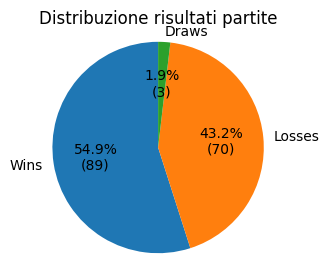

In [13]:

import pandas as pd
import matplotlib.pyplot as plt

# Carica il CSV
df = pd.read_csv("chess_games.csv")

# Conta risultati
results = df["result"].value_counts()

# Etichette più leggibili
labels_map = {
    "win": "Wins",
    "loss": "Losses",
    "draw": "Draws"
}

labels = [labels_map.get(label, label) for label in results.index]

# Pie chart
plt.figure(figsize=(3, 3))

plt.pie(
    results.values,
    labels=labels,
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100 * results.sum()))})",
    startangle=90
)

plt.title("Distribuzione risultati partite")

# Mantiene il grafico circolare
plt.axis("equal")

plt.show()


Il chart mostra che vinco più partite di quante ne perdo con una percentuale di draw davvero davvero piccola. Visto che è così, il mio rating è infatti migliorato da Gennaio a Maggio, confermiamolo quindi con il prossimo chart per vedere se il trend corrisponde.

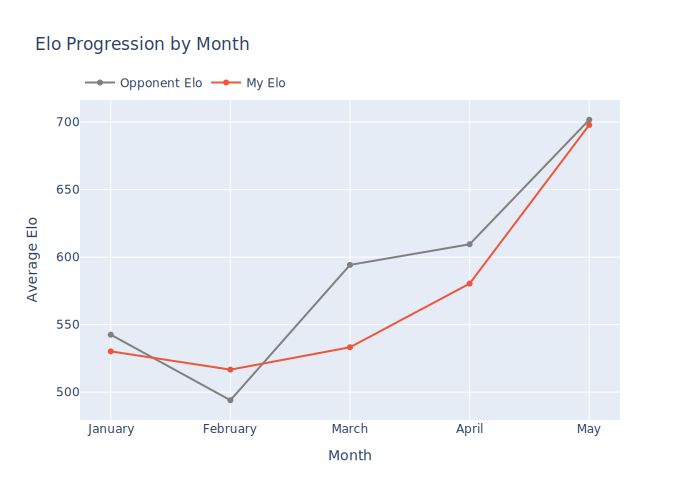

In [18]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "svg"

month_order = ["January", "February", "March", "April", "May"]

elo = df.groupby("month")[["my_rating", "opp_rating"]].mean().reindex(month_order)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=elo.index, y=elo["opp_rating"],
    name="Opponent Elo",
    mode="lines+markers",
    line=dict(color="gray", width=2),
    hovertemplate="<b>%{x}</b><br>Opponent Elo: %{y:.0f}<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=elo.index, y=elo["my_rating"],
    name="My Elo",
    mode="lines+markers",
    line=dict(width=2),
    hovertemplate="<b>%{x}</b><br>My Elo: %{y:.0f}<extra></extra>"
))

fig.update_layout(
    title="Elo Progression by Month",
    xaxis=dict(title="Month"),
    yaxis=dict(title="Average Elo"),
    hovermode="x unified",
    legend=dict(orientation="h", y=1.1)
)

fig.show()

Dal line chart si evince come...

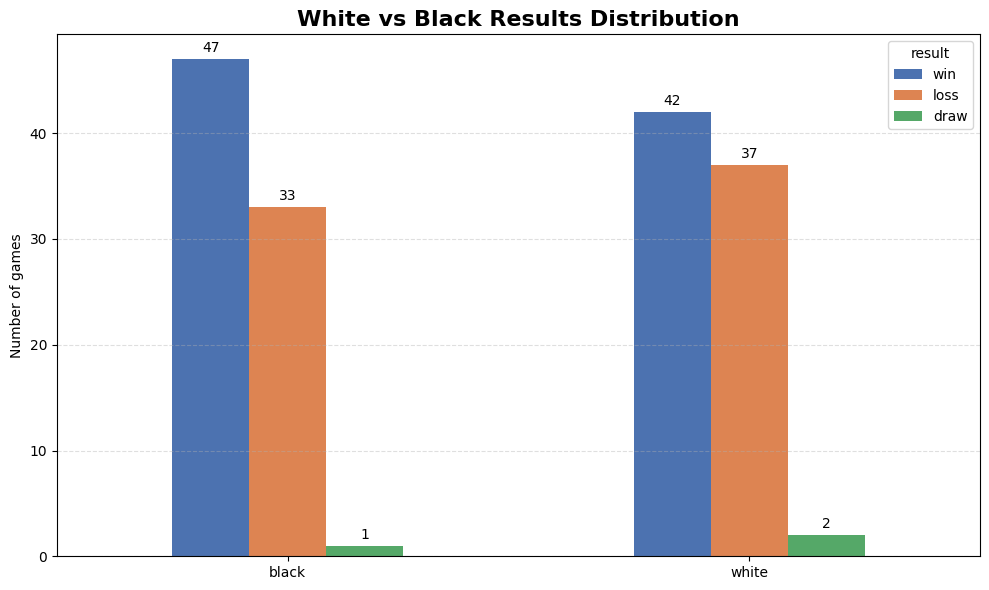

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# PREPARAZIONE DATI
# -----------------------------
data = df.dropna(subset=["my_color", "result"]).copy()

data["my_color"] = data["my_color"].str.lower()
data["result"] = data["result"].str.lower()

# tabella conteggi
pivot = pd.crosstab(data["my_color"], data["result"])

# assicura tutte le colonne
for col in ["win", "loss", "draw"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot = pivot[["win", "loss", "draw"]]

# -----------------------------
# GRAFICO
# -----------------------------
ax = pivot.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#4C72B0", "#DD8452", "#55A868"]  # win, loss, draw
)

plt.title("White vs Black Results Distribution", fontsize=16, weight="bold")
plt.xlabel("")
plt.ylabel("Number of games")
plt.xticks(rotation=0)

# valori sopra le barre
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [3]:
import requests
import pandas as pd
from datetime import datetime
import re
import time
import calendar
import matplotlib.pyplot as plt

username = "amypondz"
year = 2026
months = [1, 2, 3, 4, 5]

headers = {
    "User-Agent": "0009-0008-2026-5889"
}


def get_result(my_result):
    if my_result == "win":
        return "win"

    draw_codes = [
        "agreed",
        "repetition",
        "stalemate",
        "timevsinsufficient",
        "insufficient",
        "50move"
    ]

    return "draw" if my_result in draw_codes else "loss"


def extract_moves(pgn):
    if not pgn:
        return None

    lines = [
        l for l in pgn.strip().split("\n")
        if not l.startswith("[")
    ]

    moves_text = " ".join(lines).strip()

    moves_text = re.sub(r"\s*(1-0|0-1|1/2-1/2|\*)\s*$", "", moves_text)
    moves_text = re.sub(r"\{[^}]*\}", "", moves_text)
    moves_text = re.sub(r"\$\d+", "", moves_text)

    return re.sub(r"\s+", " ", moves_text).strip()


def clock_to_seconds(clock_str):
    h, m, s = map(int, clock_str.split(":"))
    return h * 3600 + m * 60 + s


def extract_move_times(pgn, my_color):
    """
    Estrae i secondi spesi ad ogni mossa dal giocatore.
    Usa i timestamp [%clk ...] presenti nel PGN.
    """

    if not pgn:
        return []

    clk_pattern = r"\[%clk (\d+:\d+:\d+)\]"
    clocks = re.findall(clk_pattern, pgn)

    if len(clocks) < 2:
        return []

    clocks_sec = [clock_to_seconds(c) for c in clocks]

    # White -> indici pari
    # Black -> indici dispari
    if my_color == "white":
        my_indices = range(0, len(clocks_sec), 2)
    else:
        my_indices = range(1, len(clocks_sec), 2)

    my_clocks = [
        clocks_sec[i]
        for i in my_indices
        if i < len(clocks_sec)
    ]

    spent = []

    for i in range(len(my_clocks) - 1):
        diff = my_clocks[i] - my_clocks[i + 1]

        # evita valori negativi dovuti all'incremento
        if diff >= 0:
            spent.append(diff)

    return spent


all_games = []
game_id = 0

for month in months:

    url = f"https://api.chess.com/pub/player/{username}/games/{year}/{str(month).zfill(2)}"

    print(f"Downloading {url}")

    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        print(f"Errore {response.status_code}")
        continue

    games = response.json().get("games", [])

    for game in games:

        white = game.get("white", {})
        black = game.get("black", {})
        accuracies = game.get("accuracies", {})

        if white.get("username", "").lower() == username.lower():
            my_color = "white"
            my_data = white
            opp_data = black
            my_accuracy = accuracies.get("white")
            opp_accuracy = accuracies.get("black")

        else:
            my_color = "black"
            my_data = black
            opp_data = white
            my_accuracy = accuracies.get("black")
            opp_accuracy = accuracies.get("white")

        end_dt = datetime.fromtimestamp(game["end_time"])

        start_raw = game.get("start_time")
        start_dt = datetime.fromtimestamp(start_raw) if start_raw else None

        eco_url = game.get("eco", "")

        opening = None
        eco = None

        if eco_url:

            opening = eco_url.split("/")[-1].replace("-", " ")

            match = re.search(r"/([A-E][0-9]{2})$", eco_url)

            if match:
                eco = match.group(1)

        tc = game.get("time_control", "")

        if "+" in tc:

            parts = tc.split("+")

            base_time = int(parts[0]) if parts[0].isdigit() else None
            increment = int(parts[1]) if parts[1].isdigit() else None

        elif tc.isdigit():

            base_time = int(tc)
            increment = 0

        else:

            base_time = None
            increment = None

        result = get_result(my_data.get("result"))

        move_times = extract_move_times(
            game.get("pgn"),
            my_color
        )

        all_games.append({

            "game_id": game_id,

            "date": end_dt.date(),
            "month": calendar.month_name[end_dt.month],
            "day_of_week": end_dt.strftime("%A"),
            "hour": end_dt.hour,

            "start_time": start_dt,
            "end_time": end_dt,

            "my_color": my_color,

            "my_rating": my_data.get("rating"),
            "opp_rating": opp_data.get("rating"),

            "rating_diff":
                (my_data.get("rating", 0) or 0)
                - (opp_data.get("rating", 0) or 0),

            "result": result,

            "win": int(result == "win"),
            "loss": int(result == "loss"),
            "draw": int(result == "draw"),

            "opening": opening,

            "time_control": tc,
            "base_time_sec": base_time,
            "increment_sec": increment,

            "my_accuracy": my_accuracy,
            "opp_accuracy": opp_accuracy,

            "moves": extract_moves(game.get("pgn")),

            "move_times": move_times,
            "num_moves": len(move_times)

        })

        game_id += 1

    time.sleep(1)

df = pd.DataFrame(all_games)

if df.empty:
    print("Nessuna partita trovata.")

else:

    df = df.sort_values("date").reset_index(drop=True)

    df.to_csv("chess_games.csv", index=False)

    print(f"Salvate {len(df)} partite.")

    # ==========================================================
    # SOLO PARTITE CON ALMENO 20 MOSSE
    # ==========================================================

    df20 = df[df["num_moves"] >= 15].copy()

    if df20.empty:
        print("Nessuna partita con almeno 15 mosse.")

    else:

        avg_times = []

        for move_idx in range(20):

            vals = df20["move_times"].apply(
                lambda x: x[move_idx]
            )

            avg_times.append(vals.mean())

        # ======================================================
        # GRAFICO
        # ======================================================

        plt.figure(figsize=(12, 6))

        plt.plot(
            range(1, 21),
            avg_times,
            marker="o"
        )

        plt.xlabel("Numero mossa")
        plt.ylabel("Secondi medi spesi")
        plt.title("Tempo medio impiegato nelle prime 20 mosse")

        plt.xticks(range(1, 16))

        plt.grid(True)

        plt.show()

Salvate 163 partite.
Nessuna partita con almeno 15 mosse.


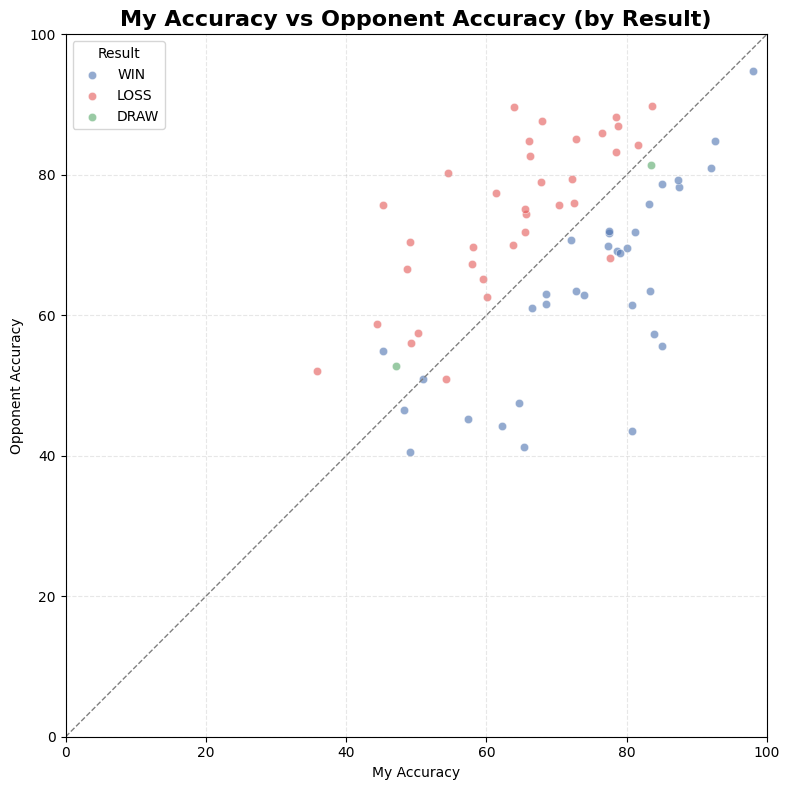

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# PREPARAZIONE DATI
# -----------------------------
data = df.dropna(subset=["my_accuracy", "opp_accuracy", "result"]).copy()

data["my_accuracy"] = pd.to_numeric(data["my_accuracy"], errors="coerce")
data["opp_accuracy"] = pd.to_numeric(data["opp_accuracy"], errors="coerce")
data["result"] = data["result"].str.lower()

data = data.dropna(subset=["my_accuracy", "opp_accuracy"])

# -----------------------------
# COLORI PER RISULTATO
# -----------------------------
colors = {
    "win": "#4C72B0",
    "loss": "#E45756",
    "draw": "#55A868"
}

# -----------------------------
# GRAFICO
# -----------------------------
plt.figure(figsize=(8, 8))

for result, color in colors.items():
    subset = data[data["result"] == result]
    plt.scatter(
        subset["my_accuracy"],
        subset["opp_accuracy"],
        alpha=0.6,
        label=result.upper(),
        c=color,
        edgecolors="white",
        linewidths=0.5
    )

# diagonale di parità
plt.plot([0, 100], [0, 100], linestyle="--", color="gray", linewidth=1)

plt.title("My Accuracy vs Opponent Accuracy (by Result)", fontsize=16, weight="bold")
plt.xlabel("My Accuracy")
plt.ylabel("Opponent Accuracy")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.legend(title="Result")
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

C:\Users\ilari\AppData\Local\Temp\ipykernel_14456\4181975987.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
C:\Users\ilari\AppData\Local\Temp\ipykernel_14456\4181975987.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["", ""])


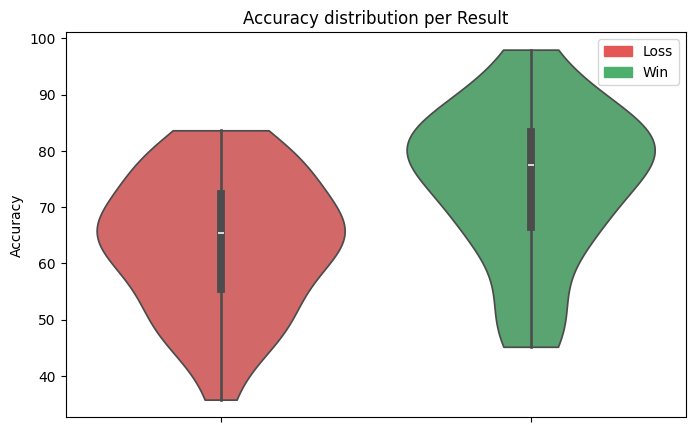

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

data = df.dropna(subset=["my_accuracy", "result"]).copy()
data = data[data["result"] != "draw"]

plt.figure(figsize=(8,5))

ax = sns.violinplot(
    x="result",
    y="my_accuracy",
    data=data,
    order=["loss", "win"],
    palette={
        "win": "#4CB06C",
        "loss": "#E45756"
    },
    cut=0
)

# -----------------------------
# RIMUOVE ETICHETTE X
# -----------------------------
ax.set_xticklabels(["", ""])

# -----------------------------
# LEGGENDA
# -----------------------------
legend_patches = [
    mpatches.Patch(color="#E45756", label="Loss"),
    mpatches.Patch(color="#4CB06C", label="Win")
]

ax.legend(handles=legend_patches, loc="upper right")

# -----------------------------
# STILE
# -----------------------------
plt.title("Accuracy distribution per Result")
plt.xlabel("")
plt.ylabel("Accuracy")

plt.show()

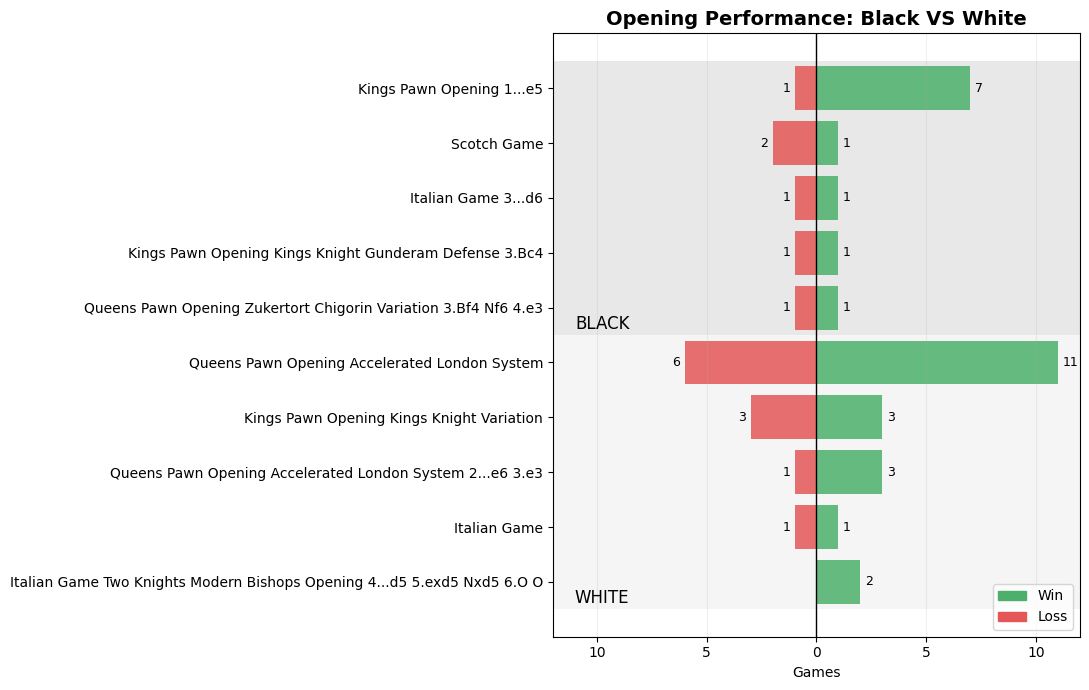

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

# -----------------------------
# DATI
# -----------------------------
data = df.dropna(subset=["opening", "my_color", "result"]).copy()

data["my_color"] = data["my_color"].str.lower()
data["result"] = data["result"].str.lower()

def top5(color):
    subset = data[data["my_color"] == color]

    table = pd.crosstab(subset["opening"], subset["result"])

    for col in ["win", "loss"]:
        if col not in table.columns:
            table[col] = 0

    table = table[["win", "loss"]]
    table["games"] = table["win"] + table["loss"]

    table = table.sort_values("games", ascending=False).head(5)

    return table.sort_values("games", ascending=True)

white = top5("white")
black = top5("black")

# -----------------------------
# LABEL
# -----------------------------
white_labels = list(white.index)
black_labels = list(black.index)

y_white = list(range(len(white)))
y_black = list(range(len(white), len(white) + len(black)))

# -----------------------------
# FIGURA
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 7))

# BACKGROUND
ax.axhspan(-0.5, len(white) - 0.5, facecolor="#F5F5F5", alpha=1)
ax.axhspan(len(white) - 0.5, len(white) + len(black) - 0.5,
           facecolor="#000000", alpha=0.09)

win_color = "#4CB06C"
loss_color = "#E45756"

# -----------------------------
# BARRE
# -----------------------------
ax.barh(y_white, -white["loss"], color=loss_color, alpha=0.85)
ax.barh(y_white,  white["win"],  color=win_color, alpha=0.85)

ax.barh(y_black, -black["loss"], color=loss_color, alpha=0.85)
ax.barh(y_black,  black["win"],  color=win_color, alpha=0.85)

# -----------------------------
# VALORI SULLE BARRE
# -----------------------------
def add_labels(values, ys, is_negative=False):
    for v, y in zip(values, ys):
        if v == 0:
            continue
        x = -v if is_negative else v
        ax.text(
            x + (-0.2 if is_negative else 0.2),
            y,
            str(int(v)),
            va="center",
            ha="right" if is_negative else "left",
            fontsize=9
        )

add_labels(white["loss"], y_white, True)
add_labels(white["win"], y_white, False)
add_labels(black["loss"], y_black, True)
add_labels(black["win"], y_black, False)

# -----------------------------
# ASSE CENTRALE
# -----------------------------
ax.axvline(0, color="black", linewidth=1)

# -----------------------------
# Y LABELS
# -----------------------------
ax.set_yticks(y_white + y_black)
ax.set_yticklabels(white_labels + black_labels, fontsize=10)

# -----------------------------
# SCALA SIMMETRICA
# -----------------------------
max_val = max(
    white[["win", "loss"]].values.max(),
    black[["win", "loss"]].values.max()
)

ax.set_xlim(-max_val - 1, max_val + 1)

# 👉 mostra valori assoluti sull'asse x
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(abs(x))}"))

# TITOLI SEZIONI (posizionati sui dati)
ax.text(
    -max_val, y_white[0] - 0.3,
    "WHITE",
    fontsize=12,
    ha="left",
    va="center"
)

ax.text(
    -max_val, y_black[0] -0.3,
    "BLACK",
    fontsize=12,
    ha="left",
    va="center"
)

# -----------------------------
# LEGEND
# -----------------------------
legend_patches = [
    mpatches.Patch(color=win_color, label="Win"),
    mpatches.Patch(color=loss_color, label="Loss")
]
ax.legend(handles=legend_patches, loc="lower right")

# -----------------------------
# STILE
# -----------------------------
ax.set_title("Opening Performance: Black VS White", fontsize=14, weight="bold")
ax.set_xlabel("Games")

ax.grid(axis="x", alpha=0.2)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

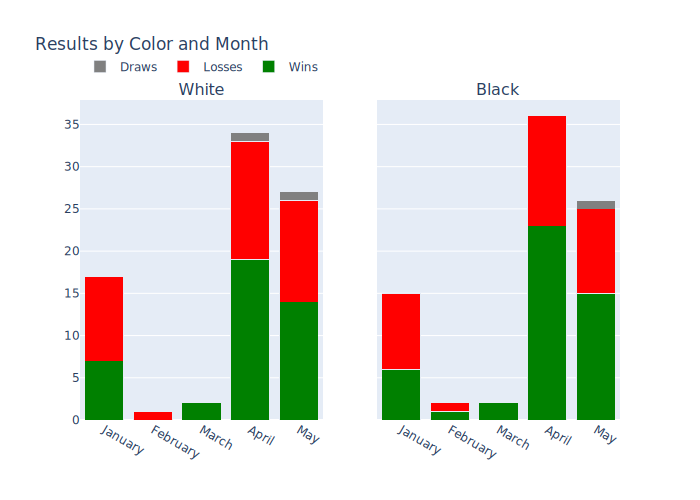

In [20]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

pio.renderers.default = "svg"

month_order = ["January", "February", "March", "April", "May"]

grouped = (
    df.groupby(["month", "my_color", "result"])
      .size()
      .unstack(fill_value=0)
      .reindex(pd.MultiIndex.from_product([month_order, ["white", "black"]], names=["month", "my_color"]))
      .fillna(0)
)

for col in ["win", "loss", "draw"]:
    if col not in grouped.columns:
        grouped[col] = 0

white = grouped.xs("white", level="my_color")
black = grouped.xs("black", level="my_color")

fig = make_subplots(rows=1, cols=2, subplot_titles=["White", "Black"], shared_yaxes=True)

for col, name, color in [("win", "Wins", "green"), ("loss", "Losses", "red"), ("draw", "Draws", "gray")]:
    fig.add_trace(go.Bar(
        x=white.index, y=white[col],
        name=name, marker_color=color,
        hovertemplate=f"<b>%{{x}}</b><br>{name}: %{{y}}<extra></extra>"
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=black.index, y=black[col],
        name=name, marker_color=color,
        showlegend=False,
        hovertemplate=f"<b>%{{x}}</b><br>{name}: %{{y}}<extra></extra>"
    ), row=1, col=2)

fig.update_layout(
    title="Results by Color and Month",
    barmode="stack",
    hovermode="x unified",
    legend=dict(orientation="h", y=1.15)
)

fig.show()

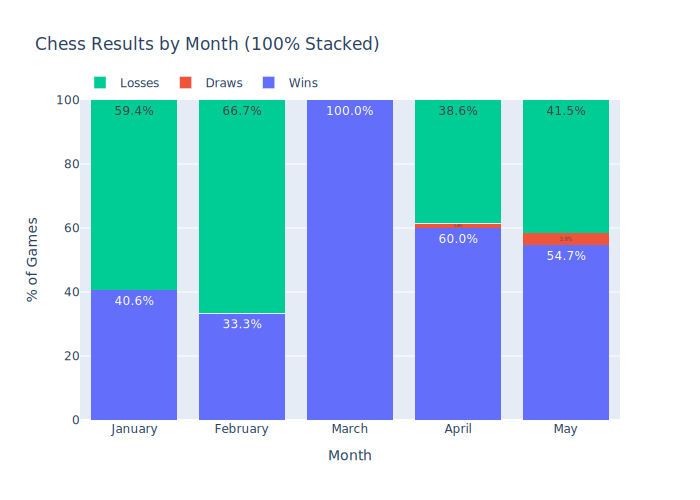

In [14]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "svg"

month_order = ["January", "February", "March", "April", "May"]

monthly_results = (
    df.groupby(["month", "result"])
      .size()
      .unstack(fill_value=0)
      .reindex(month_order)
)

for col in ["win", "loss", "draw"]:
    if col not in monthly_results.columns:
        monthly_results[col] = 0

monthly_results_pct = monthly_results.div(monthly_results.sum(axis=1), axis=0) * 100

fig = go.Figure()

for col, name in [("win", "Wins"), ("draw", "Draws"), ("loss", "Losses")]:
    fig.add_trace(go.Bar(
        x=monthly_results_pct.index,
        y=monthly_results_pct[col],
        name=name,
        text=monthly_results_pct[col].round(1).astype(str) + "%",
        textposition="inside",
        hovertemplate=f"<b>%{{x}}</b><br>{name}: %{{y:.1f}}%<extra></extra>"
    ))

fig.update_layout(
    title="Chess Results by Month (100% Stacked)",
    barmode="stack",
    hovermode="x unified",
    xaxis=dict(title="Month"),
    yaxis=dict(title="% of Games", range=[0, 100]),
    legend=dict(orientation="h", y=1.1)
)

fig.show()

In [14]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

# ==========================================================
# PREPARAZIONE DATI
# ==========================================================

days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

df["day_of_week"] = pd.Categorical(
    df["day_of_week"],
    categories=days_order,
    ordered=True
)

# conteggio partite per giorno
games_per_day = (
    df.groupby("day_of_week")
      .size()
      .reindex(days_order)
)

# ==========================================================
# DATI
# ==========================================================

values = games_per_day.values
labels = games_per_day.index.tolist()

# angoli
theta = np.linspace(
    0,
    360,
    len(values),
    endpoint=False
)

# ==========================================================
# COLORI DINAMICI
# ==========================================================

# normalizzazione valori
norm_values = (
    (values - values.min()) /
    (values.max() - values.min() + 1e-9)
)

# palette gradiente
colors = px.colors.sample_colorscale(
    "Viridis",
    norm_values
)

# ==========================================================
# GRAFICO INTERATTIVO
# ==========================================================

fig = go.Figure()

fig.add_trace(
    go.Barpolar(
        r=values,
        theta=theta,
        width=[360 / len(values) * 0.8] * len(values),

        marker=dict(
            color=values,
            colorscale="Viridis",
            line=dict(
                color="white",
                width=2
            ),
            showscale=True,
            colorbar=dict(
                title="Numero partite"
            )
        ),

        opacity=0.9,

        text=[
            f"{day}<br>{val} partite"
            for day, val in zip(labels, values)
        ],

        hovertemplate="%{text}<extra></extra>"
    )
)

# ==========================================================
# LAYOUT
# ==========================================================

fig.update_layout(

    title={
        "text": "Partite giocate per giorno della settimana",
        "x": 0.5,
        "xanchor": "center"
    },

    template="plotly_dark",

    polar=dict(

        radialaxis=dict(
            showticklabels=True,
            ticks="",
            gridcolor="rgba(255,255,255,0.15)"
        ),

        angularaxis=dict(
            tickmode="array",
            tickvals=theta,
            ticktext=labels,
            direction="clockwise",
            rotation=90
        )
    ),

    showlegend=False,

    width=600,
    height=600
)

fig.show()

C:\Users\ilari\AppData\Local\Temp\ipykernel_6396\1978922701.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("day_of_week")


In [26]:
import pandas as pd
import plotly.graph_objects as go

# ==========================================================
# GIORNI
# ==========================================================

days_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

df["day_of_week"] = pd.Categorical(
    df["day_of_week"],
    categories=days_order,
    ordered=True
)

# ==========================================================
# FASCE 3H
# ==========================================================

df["time_block"] = df["hour"] // 3

grid = (
    df.groupby(["day_of_week", "time_block"])
      .size()
      .unstack(fill_value=0)
      .reindex(days_order)
)

grid = grid.reindex(columns=range(8), fill_value=0)

# ==========================================================
# COLORI: SCACCHIERA (LEGNO → NERO)
# ==========================================================

wood_black = [
    [0.0, "#f5e6d3"],  # beige legno chiaro
    [0.25, "#d2b48c"], # tan / legno
    [0.5, "#8b5a2b"],  # marrone scuro
    [0.75, "#3b2f2f"], # quasi nero marrone
    [1.0, "#000000"]   # nero pieno
]

# ==========================================================
# HEATMAP
# ==========================================================

fig = go.Figure(
    data=go.Heatmap(
        z=grid.values,
        x=[f"{i*3}-{i*3+3}" for i in range(8)],
        y=days_order,

        colorscale=wood_black,
        zmin=0,
        zmax=grid.values.max(),

        colorbar=dict(title="Games"),

        hovertemplate=
            "Day: %{y}<br>"
            "Block: %{x}<br>"
            "Games: %{z}<extra></extra>"
    )
)

fig.update_layout(
    title="Playing chess during the night...",
    xaxis_title="Time (3-hour blocks)",
    yaxis_title="",
    width=900,
    height=600
)

fig.show()

C:\Users\ilari\AppData\Local\Temp\ipykernel_6396\1323408524.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["day_of_week", "time_block"])


In [41]:
hour_acc = df.groupby("hour")["my_accuracy"].mean()

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=hour_acc.index,
        y=hour_acc.values,
        mode="lines+markers"
    )
)

fig.update_layout(
    title="Average Accuracy by Hour",
    xaxis_title="Hour",
    yaxis_title="Accuracy"
)

fig.show()

In [40]:

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ==========================================================
# PREPARAZIONE
# ==========================================================

df = df.sort_values("end_time").reset_index(drop=True)

df["is_loss"] = (df["result"] == "loss").astype(int)

# loss streak
df["loss_streak"] = df["is_loss"].groupby(
    (df["is_loss"] != df["is_loss"].shift()).cumsum()
).cumsum()

# prev loss
df["prev_loss"] = df["is_loss"].shift(1).fillna(0)

# rolling accuracy
df["rolling_acc"] = df["my_accuracy"].rolling(5).mean()

# ==========================================================
# 1) LOSS STREAK vs ACCURACY (INTERATTIVO)
# ==========================================================

fig1 = px.scatter(
    df,
    x="loss_streak",
    y="my_accuracy",
    trendline="ols",
    title="Does losing streak affect accuracy?"
)

fig1.update_traces(marker=dict(opacity=0.4))

fig1.show()

# ==========================================================
# 2) POST-LOSS EFFECT (INTERATTIVO)
# ==========================================================

fig2 = px.box(
    df,
    x="prev_loss",
    y="my_accuracy",
    points="all",
    title="Does losing affect next-game accuracy?"
)

fig2.update_xaxes(
    tickvals=[0, 1],
    ticktext=["No previous loss", "After loss"]
)

fig2.show()
